# WLS Chain Spectra: Ar / Xe $\to$ TPB $\to$ Y11 $\to$ MPPC

Combined view of the full wavelength-shifting (WLS) chain used in CIGAR: noble-gas VUV scintillation (Ar or Xe), the TPB absorption/emission pair, the Y11 fiber absorption/emission pair, and the Hamamatsu SiPM (SiPM) photon detection efficiency (PDE).

**Note on the data:** all curves below are digitized/approximated from the published reference figures and datasheets listed under *References*, to reproduce peak position, shape, and spectral overlap at each step — they are illustrative, not measured or datasheet-precision values. The Ar/Xe linewidths (FWHM $\approx$ 10 nm / 15 nm) are typical literature values for the noble-gas second continuum; the source below gives the peak positions (128 nm / 175 nm) but not an exact linewidth. Replace the control points in the data cell with real digitized/datasheet points if precision matters.

**References**
1. M. Agostini et al., *"Liquid argon light collection and veto modeling in GERDA Phase II,"* Eur. Phys. J. C, 83(4):319, 2023 — TPB emission/absorption, as cited in the CIGAR paper.
2. V. M. Gehman et al., *NIM A* 654 (2011) 116 — visible re-emission spectrum of TPB films.
3. Kuraray, *"Plastic fibers"* datasheet, 2026 — Y11 multi-clad WLS fiber absorption/emission.
4. Hamamatsu, *"SiPM S13360-6075PE"* technical datasheet, 2026 — SiPM PDE.
5. M. Suzuki and S. Kubota (1979); T. Takahashi et al. (1983) — Ar (128 nm) / Xe ($\sim$175 nm) second-continuum VUV emission, via L. Larizgoitia's thesis.

**Styling convention used throughout:** each *species* gets one fixed (color, linestyle) pair, reused identically for every curve of that species in every layout below — so absorption and emission of the same species always look the same, and it's obvious at a glance which lines belong together:

| Species | Color | Linestyle |
|---|---|---|
| Ar (emission only) | black | solid `-` |
| Xe (emission only) | very dark gray | dashed `--` |
| TPB (absorption + emission) | medium-dark gray | dash-dot `-.` |
| Y11 (absorption + emission) | medium-light gray | dotted `:` |
| SiPM / SiPM (PDE only) | light gray | long-dash |

Every layout also keeps emission/absorption (a.u.) and PDE (%) on separate y-axes, since they're different physical quantities.

Three layout options:
1. Three separate mirrored plots, one per WLS stage, each with its own dual y-axis (Ar/Xe emission vs. TPB absorption; TPB emission vs. Y11 absorption; Y11 emission vs. SiPM PDE)
2. A single plot with dual y-axes, all seven curves plotted upward (a.u. on the left, PDE % on the right)
3. A single plot with dual y-axes, mirrored — all emission curves and TPB/Y11 absorption share the left (a.u.) axis, up for emission / down for absorption; SiPM PDE is mirrored down on its own right (%) axis. Legends are split in two, one per quadrant.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from matplotlib.ticker import FuncFormatter

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
# colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']
# Wong (2011) colorblind-safe palette – 8 distinct colors
# Works for deuteranopia, protanopia, and tritanopia

# Grayscale palette – 10 shades from near-black to light gray
# Paired with distinct markers and line styles for full grayscale legibility
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown
    '#006CD1',  # Cerulean
]

colors = GS_COLORS

# Distinct markers and line styles for extra redundancy (grayscale-safe)
CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']

In [4]:
font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size

## Spectral data (digitized/approximate)

In [ ]:
def _pchip_curve(control_points, x_grid):
    """Smooth, monotonic-safe interpolation through hand-picked (wavelength, value) points.
    Points outside the given x-range fall back to 0 (extrapolate=False + nan_to_num)."""
    xs, ys = zip(*control_points)
    interp = PchipInterpolator(np.array(xs, dtype=float), np.array(ys, dtype=float), extrapolate=False)
    y = np.nan_to_num(interp(x_grid), nan=0.0)
    return np.clip(y, 0, None)


def _gaussian_curve(mu, fwhm, x_grid):
    """Narrow VUV emission bands (Ar/Xe second continuum) are close to Gaussian."""
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return np.exp(-0.5 * ((x_grid - mu) / sigma) ** 2)


wavelength = np.linspace(100, 800, 2801)  # nm — spans the Ar/Xe VUV lines through the SiPM red tail

# Ar / Xe second-continuum VUV emission — peak positions from Suzuki & Kubota (1979) /
# Takahashi et al. (1983); FWHM are typical literature values, not from a specific digitized curve.
ar_emission = _gaussian_curve(mu=128, fwhm=10, x_grid=wavelength)
xe_emission = _gaussian_curve(mu=175, fwhm=15, x_grid=wavelength)

# TPB absorption — saturated (~1) from the VUV up to ~330 nm, falling to 0 by ~440 nm
# (Agostini et al. 2023; Gehman et al. 2011).
tpb_absorption_pts = [
    (100, 1.00), (150, 1.00), (200, 1.00), (250, 0.99), (280, 0.98),
    (300, 0.98), (320, 0.93), (340, 0.82), (355, 0.65), (370, 0.45),
    (385, 0.26), (400, 0.13), (412, 0.05), (425, 0.015), (440, 0), (800, 0),
]

# TPB visible re-emission spectrum (Gehman et al. 2011; Agostini et al. 2023).
tpb_emission_pts = [
    (300, 0), (365, 0), (375, 0.05), (390, 0.35), (400, 0.55),
    (410, 0.85), (420, 1.00), (430, 0.85), (440, 0.55), (450, 0.38),
    (460, 0.30), (470, 0.26), (480, 0.22), (500, 0.15), (520, 0.10),
    (550, 0.05), (570, 0.02), (580, 0), (800, 0),
]

# Y11 multi-clad WLS fiber absorption spectrum (Kuraray datasheet) — single
# broad band peaking ~415 nm, not the double-humped shape used previously.
y11_absorption_pts = [
    (300, 0), (340, 0), (350, 0.05), (365, 0.25), (380, 0.55),
    (395, 0.80), (405, 0.92), (415, 1.00), (425, 0.95), (435, 0.80),
    (445, 0.60), (455, 0.42), (465, 0.27), (475, 0.15), (485, 0.07),
    (495, 0.02), (505, 0), (800, 0),
]

# Y11 multi-clad WLS fiber emission spectrum (Kuraray datasheet).
y11_emission_pts = [
    (300, 0), (430, 0), (445, 0.10), (455, 0.35), (465, 0.70),
    (472, 0.95), (476, 1.00), (480, 0.90), (488, 0.65), (495, 0.55),
    (502, 0.65), (508, 0.72), (515, 0.50), (525, 0.25), (535, 0.08),
    (545, 0), (800, 0),
]

# Hamamatsu SiPM S13360-6075PE photon detection efficiency (technical datasheet).
mppc_pde_pts = [
    (300, 0), (320, 3), (340, 15), (360, 30), (380, 42), (400, 48),
    (420, 49.5), (440, 50), (460, 50.5), (480, 48), (500, 45),
    (520, 42), (550, 38), (600, 32), (650, 28), (700, 24), (750, 21),
    (800, 18),
]

tpb_absorption = _pchip_curve(tpb_absorption_pts, wavelength)
tpb_emission   = _pchip_curve(tpb_emission_pts, wavelength)
y11_absorption = _pchip_curve(y11_absorption_pts, wavelength)
y11_emission   = _pchip_curve(y11_emission_pts, wavelength)
mppc_pde       = _pchip_curve(mppc_pde_pts, wavelength)   # % (0-100), used on its own axis everywhere

In [ ]:
# Fixed species -> (color, linestyle) mapping, reused across every layout below.
# Each species gets ONE (color, linestyle) pair; absorption and emission of the
# same species use the identical pair, so the shared identity is unmistakable —
# only axis position (up/down) and the legend text tell the two roles apart.
AR_COLOR,   AR_LS   = GS_COLORS[0], '-'              # Ar — emission only
XE_COLOR,   XE_LS   = GS_COLORS[2], '--'             # Xe — emission only
TPB_COLOR,  TPB_LS  = GS_COLORS[4], '-.'             # TPB — absorption + emission
Y11_COLOR,  Y11_LS  = GS_COLORS[6], ':'              # Y11 — absorption + emission
MPPC_COLOR, MPPC_LS = GS_COLORS[7], (0, (5, 1))      # SiPM — PDE only (long dash)

# Mirrored axes plot the "down" curve as negative data so it renders below the
# zero line; this formatter displays the original (positive) magnitude instead.
_abs_fmt = FuncFormatter(lambda v, pos: f'{abs(v):g}')

## Format 1 — three separate plots, each with its own dual y-axis

One subplot per WLS stage, each mirrored with independent left/right axes:
- **Ar / Xe emission** (up, left, a.u.) vs. **TPB absorption** (down, right, a.u.)
- **TPB emission** (up, left, a.u.) vs. **Y11 absorption** (down, right, a.u.)
- **Y11 emission** (up, left, a.u.) vs. **SiPM PDE** (down, right, real %)

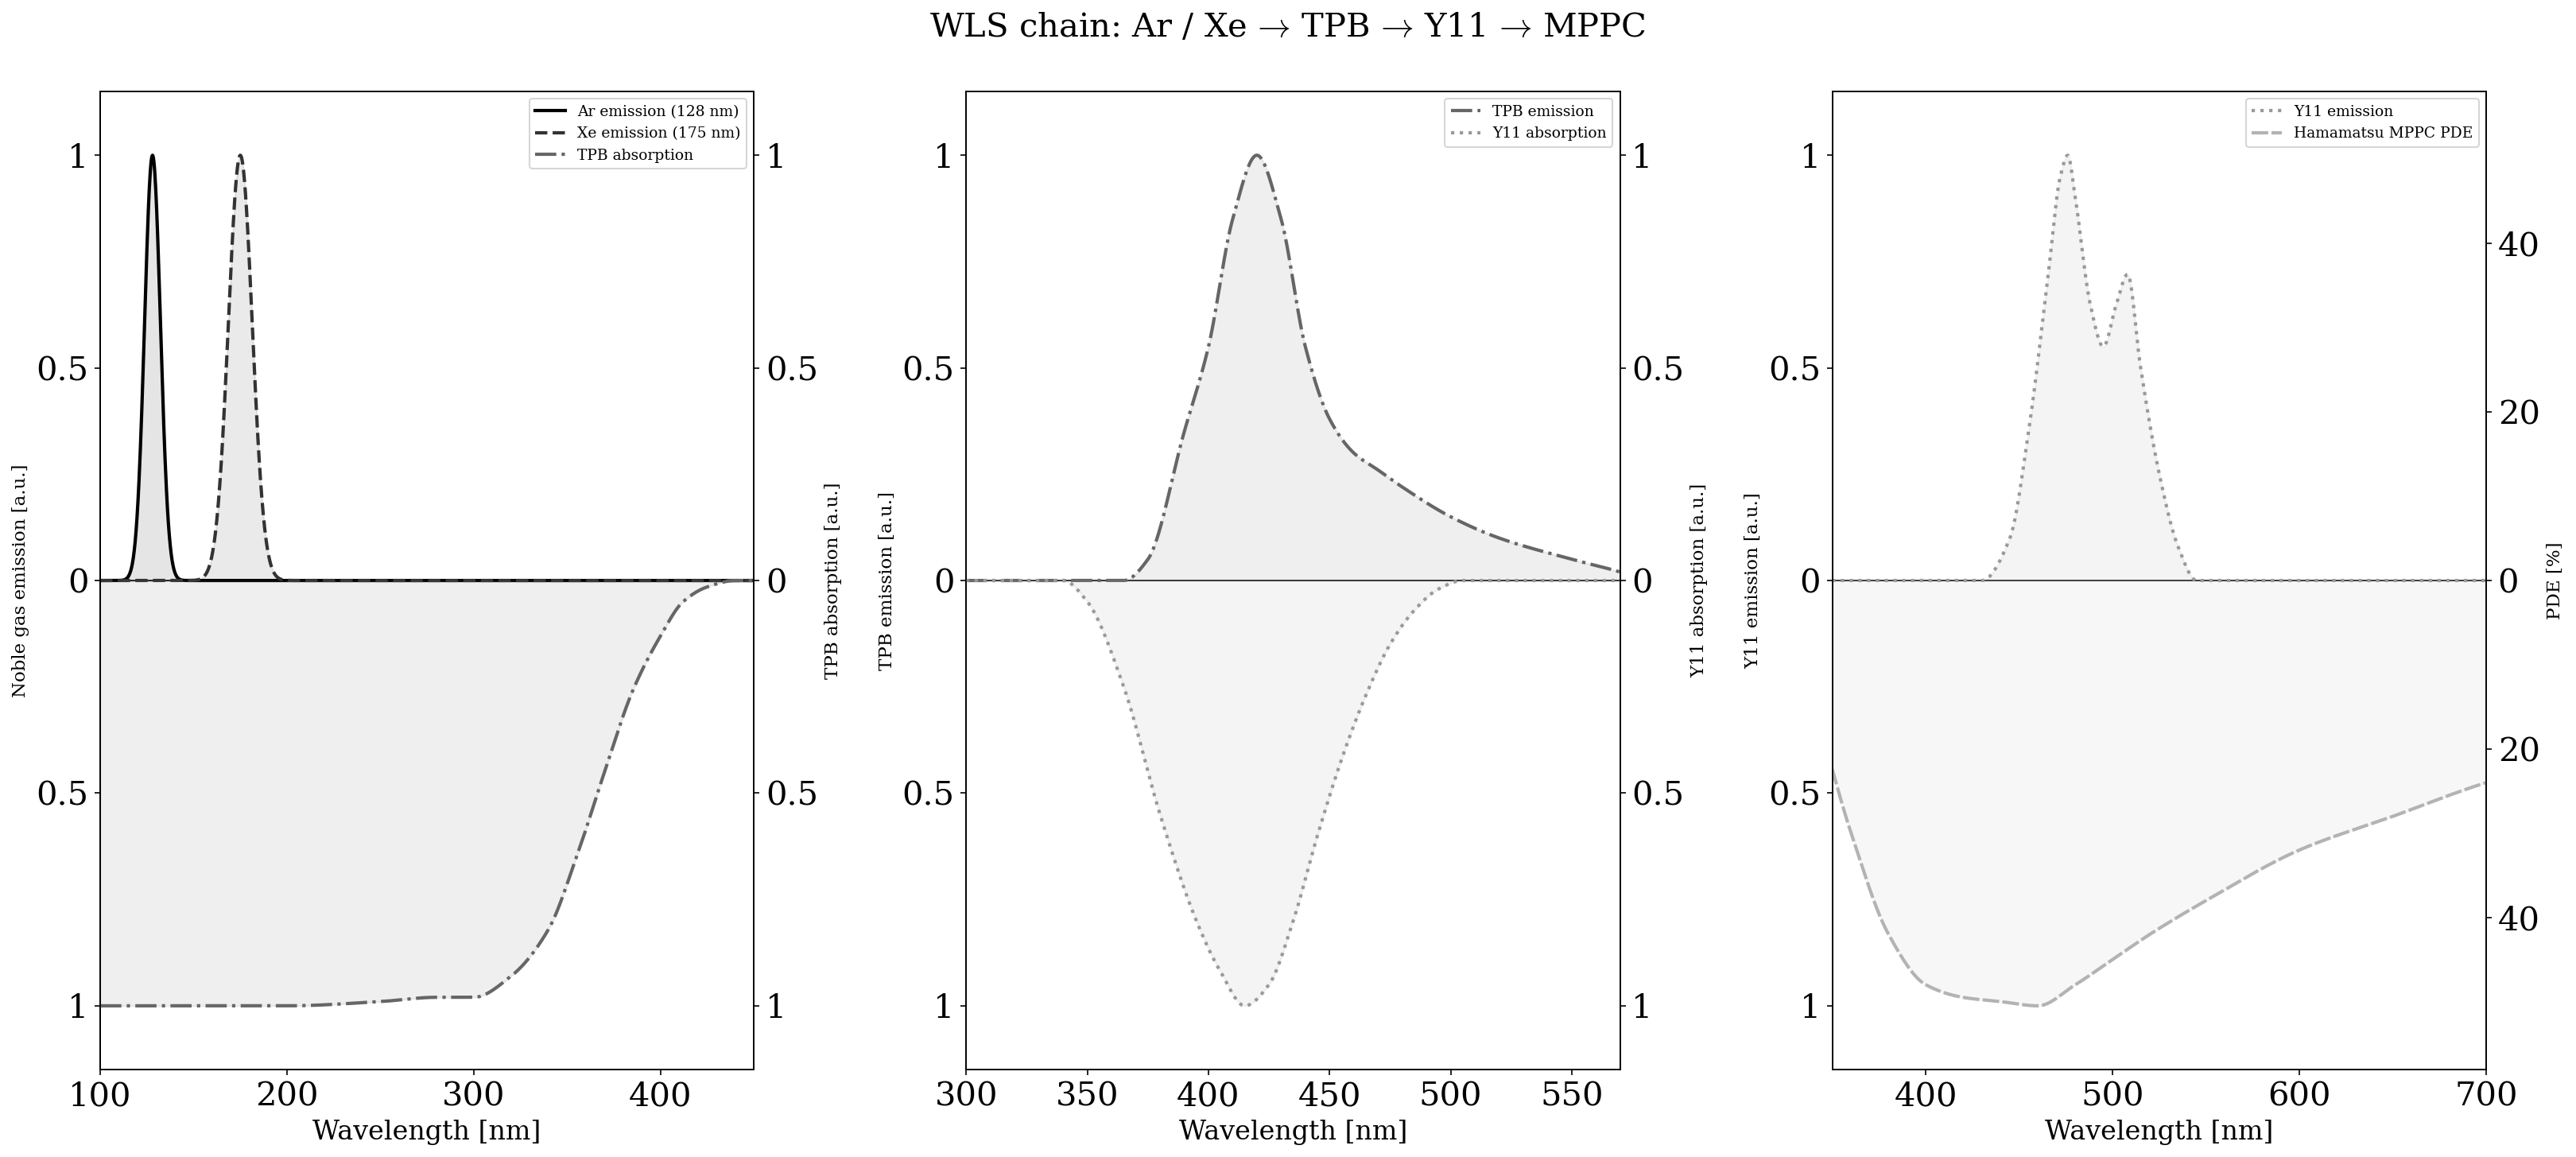

In [ ]:
def plot_mirrored_dual(ax_left, x, up_curves, ylabel_up, down_curves, ylabel_down, xlim):
    """up_curves / down_curves: list of (y, label, color, ls) tuples sharing one axis each."""
    ax_right = ax_left.twinx()

    # Symmetric ylim on each axis puts 0 at the vertical center for both axes,
    # independent of their (different) data scales — that's what keeps the
    # mirror aligned even though left/right use different units.
    m_up   = max(y.max() for y, *_ in up_curves) * 1.15
    m_down = max(y.max() for y, *_ in down_curves) * 1.15
    ax_left.set_ylim(-m_up, m_up)
    ax_right.set_ylim(-m_down, m_down)

    for y, label, color, ls in up_curves:
        ax_left.plot(x, y, color=color, linestyle=ls, lw=2, label=label)
        ax_left.fill_between(x, 0, y, color=color, alpha=0.10)

    for y, label, color, ls in down_curves:
        ax_right.plot(x, -y, color=color, linestyle=ls, lw=2, label=label)
        ax_right.fill_between(x, 0, -y, color=color, alpha=0.10)

    ax_left.axhline(0, color=GS_COLORS[0], lw=0.8, zorder=0)
    ax_left.set_xlim(*xlim)

    ax_left.yaxis.set_major_formatter(_abs_fmt)
    ax_right.yaxis.set_major_formatter(_abs_fmt)
    ax_left.set_ylabel(ylabel_up, fontsize=font_size * 0.55)
    ax_right.set_ylabel(ylabel_down, fontsize=font_size * 0.55)
    ax_left.set_xlabel('Wavelength [nm]', fontsize=font_size * 0.8)

    lines_l, labels_l = ax_left.get_legend_handles_labels()
    lines_r, labels_r = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_l + lines_r, labels_l + labels_r, fontsize=font_size * 0.45, loc='upper right')


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 10), dpi=150)

plot_mirrored_dual(ax1, wavelength,
                    up_curves=[(ar_emission, 'Ar emission (128 nm)', AR_COLOR, AR_LS),
                               (xe_emission, 'Xe emission (175 nm)', XE_COLOR, XE_LS)],
                    ylabel_up='Noble gas emission [a.u.]',
                    down_curves=[(tpb_absorption, 'TPB absorption', TPB_COLOR, TPB_LS)],
                    ylabel_down='TPB absorption [a.u.]',
                    xlim=(100, 450))

plot_mirrored_dual(ax2, wavelength,
                    up_curves=[(tpb_emission, 'TPB emission', TPB_COLOR, TPB_LS)],
                    ylabel_up='TPB emission [a.u.]',
                    down_curves=[(y11_absorption, 'Y11 absorption', Y11_COLOR, Y11_LS)],
                    ylabel_down='Y11 absorption [a.u.]',
                    xlim=(300, 570))

plot_mirrored_dual(ax3, wavelength,
                    up_curves=[(y11_emission, 'Y11 emission', Y11_COLOR, Y11_LS)],
                    ylabel_up='Y11 emission [a.u.]',
                    down_curves=[(mppc_pde, 'Hamamatsu SiPM PDE', MPPC_COLOR, MPPC_LS)],
                    ylabel_down='PDE [%]',
                    xlim=(350, 700))

fig.suptitle('WLS chain: Ar / Xe $\\to$ TPB $\\to$ Y11 $\\to$ MPPC', fontsize=font_size)
plt.tight_layout()
plt.show()

## Format 2 — single plot, dual y-axis, all curves up

All seven curves on one wavelength axis: emission/absorption (a.u., left axis) and PDE (%, right axis). A dual-axis plot lets any two curves be repositioned relative to each other just by rescaling one axis — treat visual overlap here qualitatively, not as a real efficiency product.

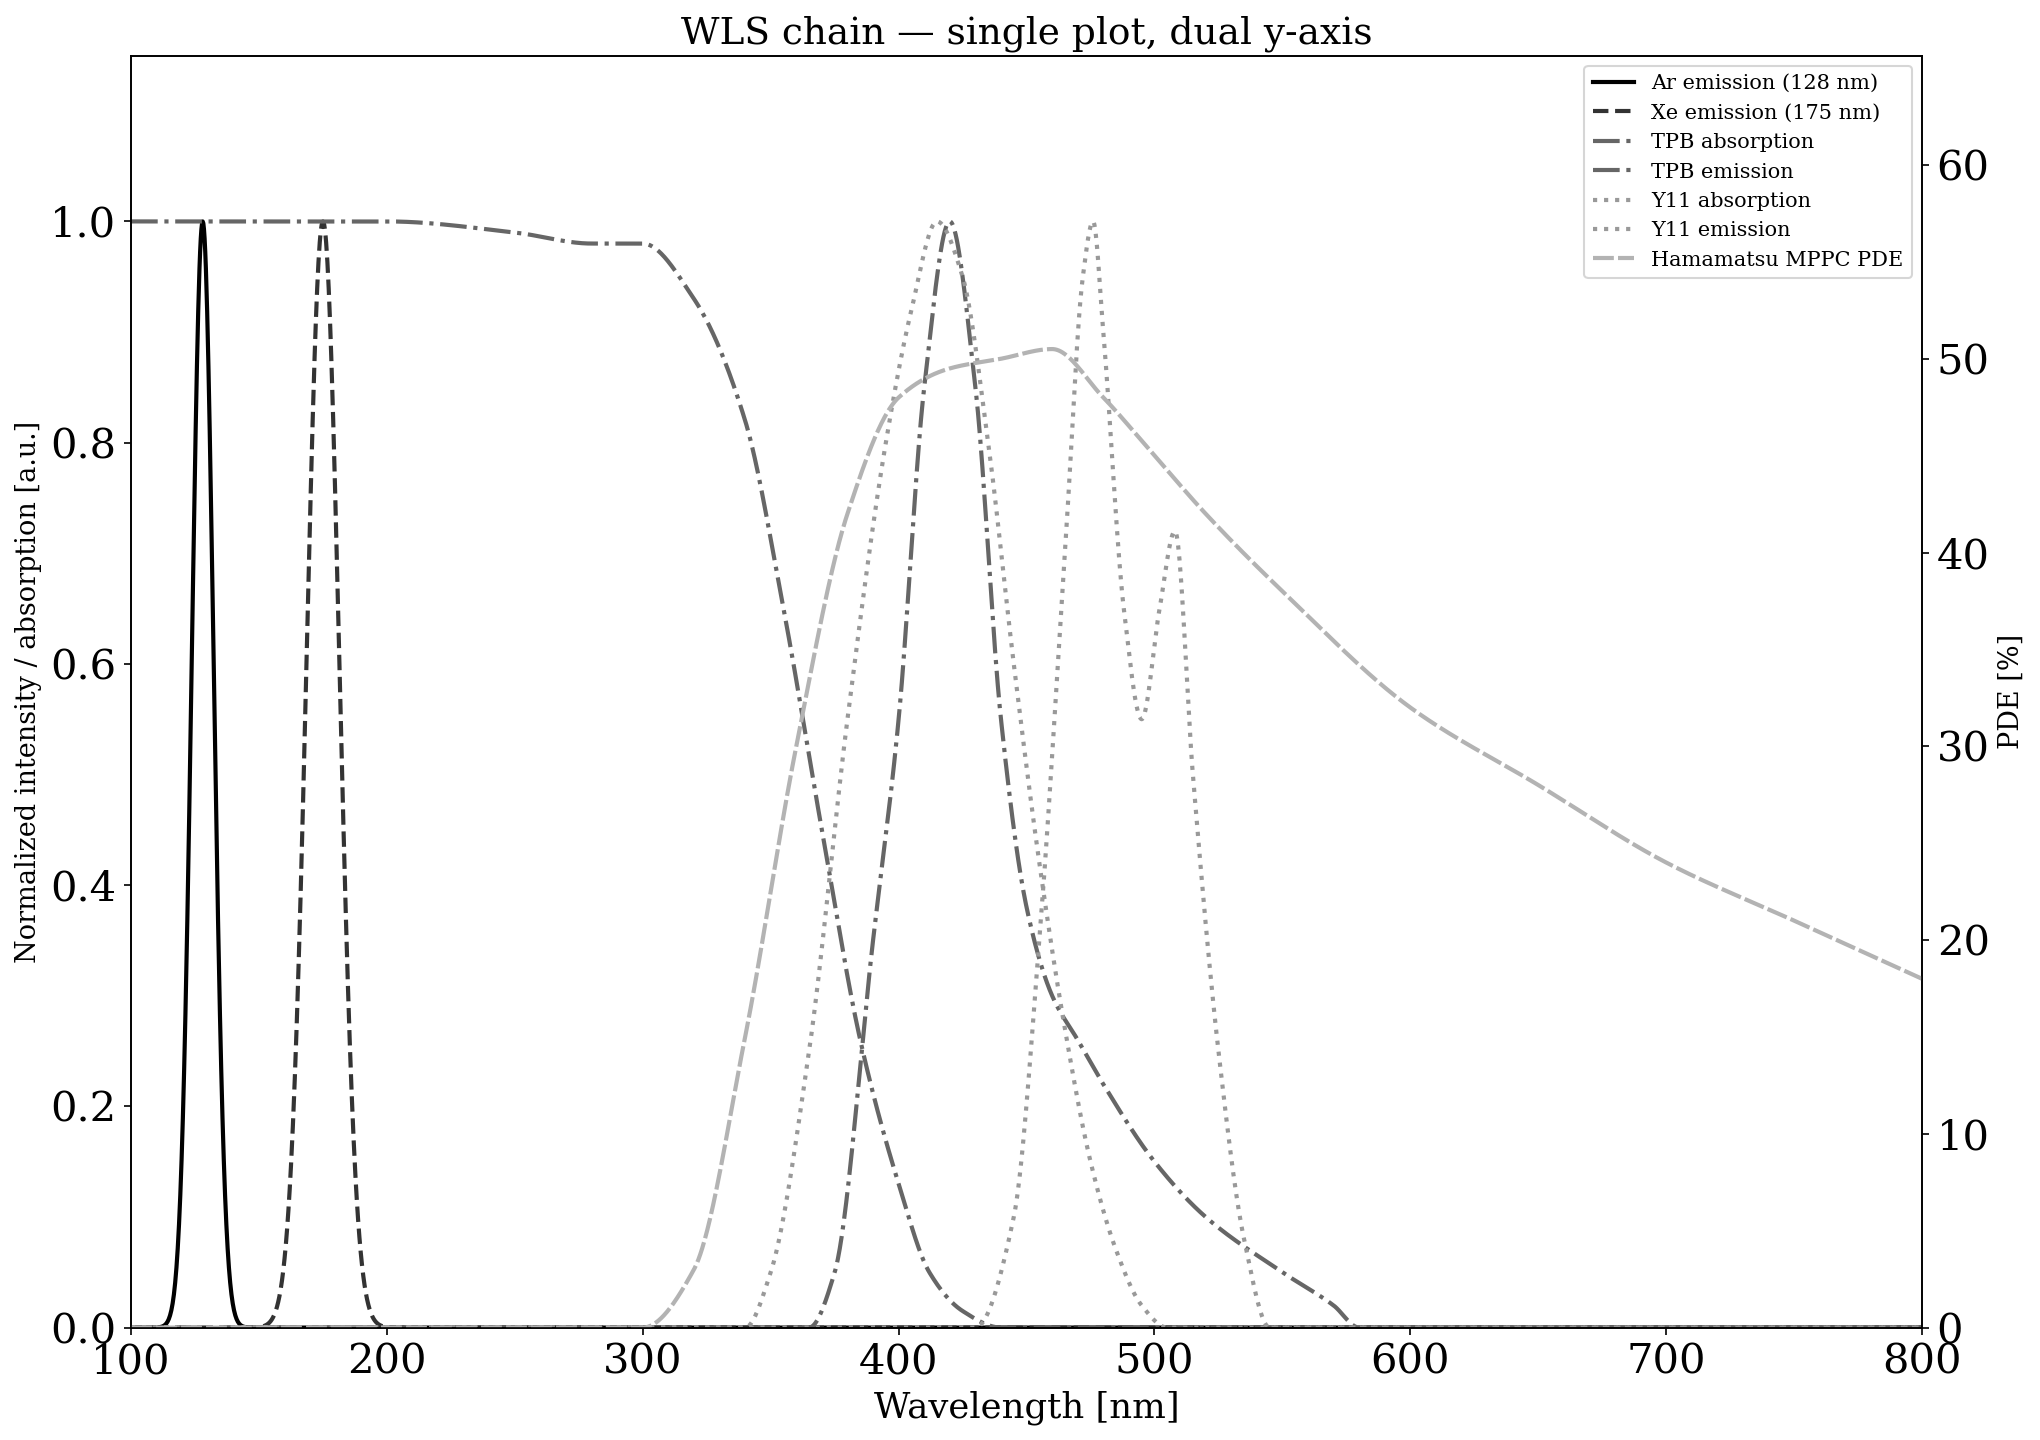

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 10), dpi=150)
ax2 = ax1.twinx()

ax1.plot(wavelength, ar_emission,    color=AR_COLOR,   ls=AR_LS,   lw=2, label='Ar emission (128 nm)')
ax1.plot(wavelength, xe_emission,    color=XE_COLOR,   ls=XE_LS,   lw=2, label='Xe emission (175 nm)')
ax1.plot(wavelength, tpb_absorption, color=TPB_COLOR,  ls=TPB_LS,  lw=2, label='TPB absorption')
ax1.plot(wavelength, tpb_emission,   color=TPB_COLOR,  ls=TPB_LS,  lw=2, label='TPB emission')
ax1.plot(wavelength, y11_absorption, color=Y11_COLOR,  ls=Y11_LS,  lw=2, label='Y11 absorption')
ax1.plot(wavelength, y11_emission,   color=Y11_COLOR,  ls=Y11_LS,  lw=2, label='Y11 emission')
ax2.plot(wavelength, mppc_pde,       color=MPPC_COLOR, ls=MPPC_LS, lw=2, label='Hamamatsu SiPM PDE')

ax1.set_xlabel('Wavelength [nm]', fontsize=font_size * 0.85)
ax1.set_ylabel('Normalized intensity / absorption [a.u.]', fontsize=font_size * 0.65)
ax2.set_ylabel('PDE [%]', fontsize=font_size * 0.65)
ax1.set_xlim(100, 800)
ax1.set_ylim(0, 1.15)
ax2.set_ylim(0, mppc_pde.max() * 1.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=font_size * 0.5, loc='upper right')

ax1.set_title('WLS chain — single plot, dual y-axis', fontsize=font_size * 0.9)
plt.tight_layout()
plt.show()

## Format 3 — single plot, dual y-axis, mirrored, split legends

- **Left axis (a.u.):** every emission curve (Ar, Xe, TPB, Y11) plotted **up**; TPB and Y11 absorption mirrored **down** — all six share this one axis since they're the same (arbitrary) unit. The "up" and "down" halves get their own axis label instead of one label for the whole axis.
- **Right axis (%):** Hamamatsu SiPM PDE mirrored **down** on its own real-percent scale, labeled only for that down half (there's no "up" data on this axis).
- TPB and Y11 each use one fixed (color, linestyle) for both their absorption and emission curves — same line format up and down marks them as the same species.
- Ar and Xe are both solid lines, identified by a text label next to each peak instead of a legend entry — same direct-labeling treatment now also applied to TPB, Y11, and SiPM so every curve is identifiable at a glance without reading a legend.
- Two untitled legends remain for the curves not directly labeled next to their peak: one in the upper-right quadrant (emission / up curves) and one in the lower-right quadrant (absorption + PDE / down curves).

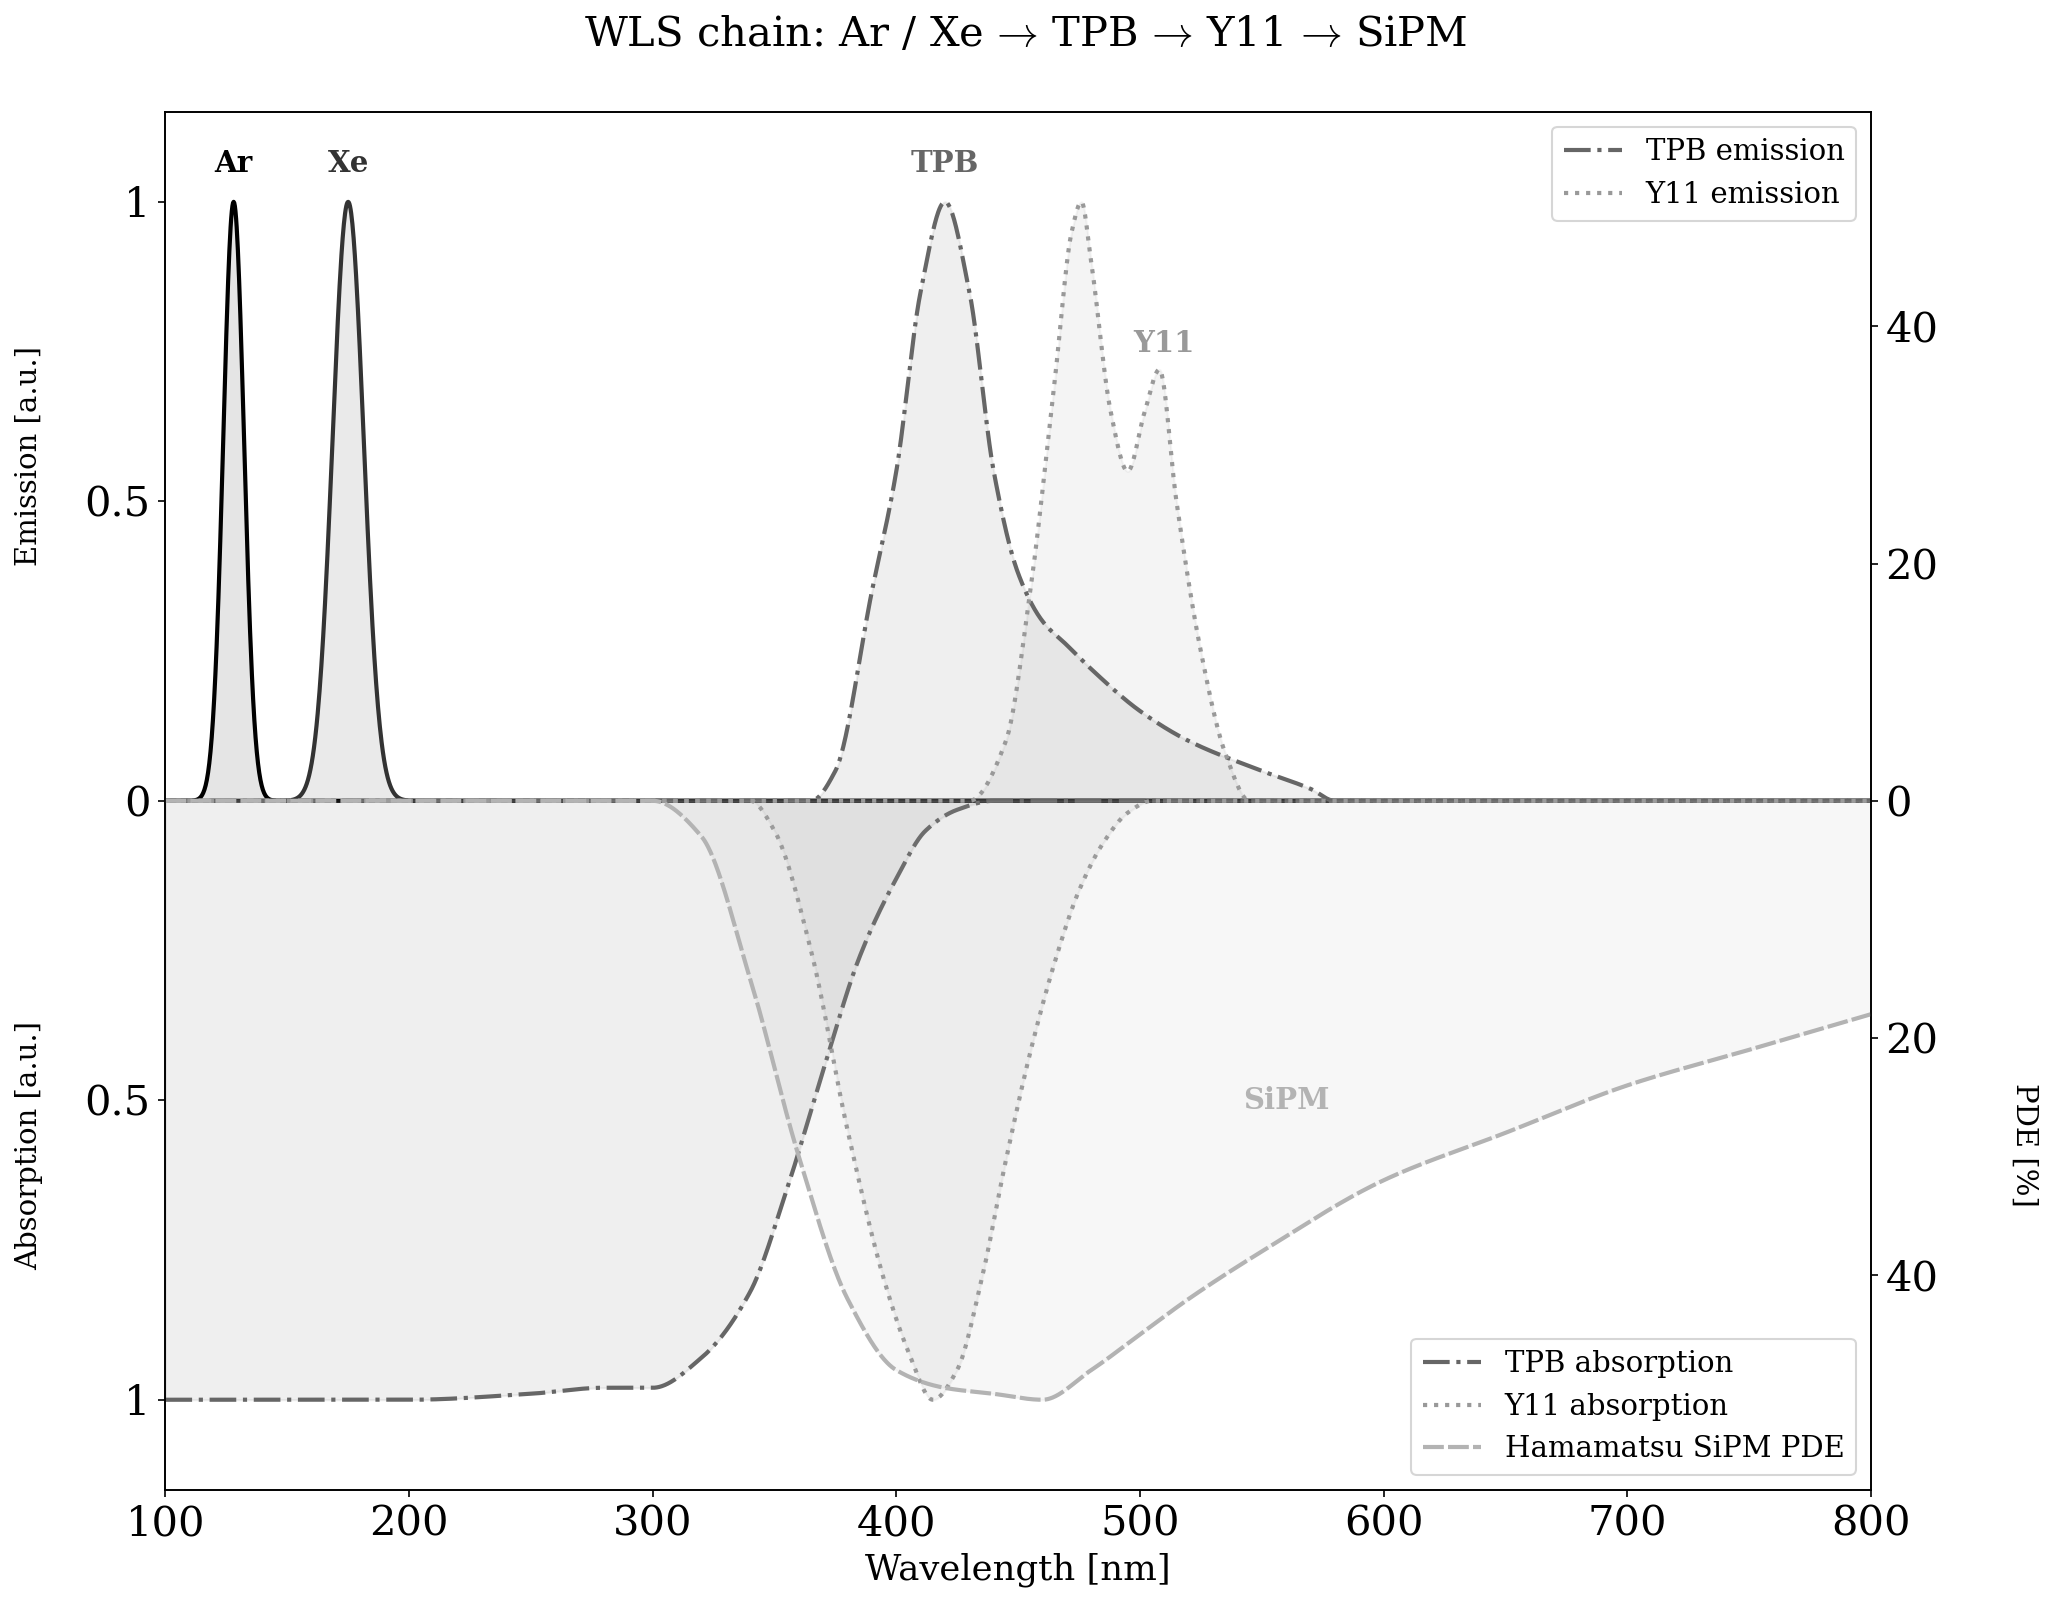

In [18]:
fig, ax_left = plt.subplots(figsize=(14, 11), dpi=150)
ax_right = ax_left.twinx()

# Local override for this plot only: both noble-gas curves solid (color still tells them apart).
AR_LS_SOLID, XE_LS_SOLID = '-', '-'

m_left = max(ar_emission.max(), xe_emission.max(), tpb_emission.max(), y11_emission.max(),
             tpb_absorption.max(), y11_absorption.max()) * 1.15
m_right = mppc_pde.max() * 1.15
ax_left.set_ylim(-m_left, m_left)
ax_right.set_ylim(-m_right, m_right)

up_handles, down_handles = [], []

# Ar and Xe are plotted but excluded from the legend — they get inline peak labels instead.
ax_left.plot(wavelength, ar_emission, color=AR_COLOR, linestyle=AR_LS_SOLID, lw=2)
ax_left.fill_between(wavelength, 0, ar_emission, color=AR_COLOR, alpha=0.10)
ax_left.plot(wavelength, xe_emission, color=XE_COLOR, linestyle=XE_LS_SOLID, lw=2)
ax_left.fill_between(wavelength, 0, xe_emission, color=XE_COLOR, alpha=0.10)

for y, label, color, ls in [
    (tpb_emission, 'TPB emission', TPB_COLOR, TPB_LS),
    (y11_emission, 'Y11 emission', Y11_COLOR, Y11_LS),
]:
    h, = ax_left.plot(wavelength, y, color=color, linestyle=ls, lw=2, label=label)
    ax_left.fill_between(wavelength, 0, y, color=color, alpha=0.10)
    up_handles.append(h)

for y, label, color, ls in [
    (tpb_absorption, 'TPB absorption', TPB_COLOR, TPB_LS),
    (y11_absorption, 'Y11 absorption', Y11_COLOR, Y11_LS),
]:
    h, = ax_left.plot(wavelength, -y, color=color, linestyle=ls, lw=2, label=label)
    ax_left.fill_between(wavelength, 0, -y, color=color, alpha=0.10)
    down_handles.append(h)

h, = ax_right.plot(wavelength, -mppc_pde, color=MPPC_COLOR, linestyle=MPPC_LS, lw=2, label='Hamamatsu SiPM PDE')
ax_right.fill_between(wavelength, 0, -mppc_pde, color=MPPC_COLOR, alpha=0.10)
down_handles.append(h)

ax_left.axhline(0, color=GS_COLORS[0], lw=0.8, zorder=0)
ax_left.set_xlim(100, 800)
ax_left.yaxis.set_major_formatter(_abs_fmt)
ax_right.yaxis.set_major_formatter(_abs_fmt)
ax_left.set_xlabel('Wavelength [nm]', fontsize=font_size * 0.85)

# Split y-axis labels: "up" and "down" each get their own label instead of one for the whole axis.
label_kw = dict(transform=ax_left.transAxes, rotation=90, ha='center', va='center',
                 fontsize=font_size * 0.7, clip_on=False)
ax_left.text(-0.08, 0.75, 'Emission [a.u.]', **label_kw)
ax_left.text(-0.08, 0.25, 'Absorption [a.u.]', **label_kw)
ax_right.text(1.09, 0.25, 'PDE [%]', transform=ax_left.transAxes, rotation=-90,
              ha='center', va='center', fontsize=font_size * 0.7, clip_on=False)

# Inline peak labels — one per species, colored/styled to match its curve, with a
# translucent backing box for legibility (same treatment for every species).
peak_label_kw = dict(ha='center', fontsize=font_size * 0.7, fontweight='bold',
                      bbox=dict(boxstyle='round,pad=0.2', facecolor='none', edgecolor='none', alpha=0.75))
ax_left.text(128, 1.05, 'Ar', color=AR_COLOR, **peak_label_kw)
ax_left.text(175, 1.05, 'Xe', color=XE_COLOR, **peak_label_kw)
ax_left.text(420, 1.05, 'TPB', color=TPB_COLOR, **peak_label_kw)
ax_left.text(510, 0.75, 'Y11', color=Y11_COLOR, **peak_label_kw)
ax_right.text(560, -mppc_pde.max() * 0.5, 'SiPM', color=MPPC_COLOR, va='center', **peak_label_kw)

legend_up = ax_left.legend(handles=up_handles, loc='upper right', fontsize=font_size * 0.7, frameon=True)
ax_left.add_artist(legend_up)
legend_down = ax_left.legend(handles=down_handles, loc='lower right', fontsize=font_size * 0.7, frameon=True)

fig.suptitle('WLS chain: Ar / Xe $\\to$ TPB $\\to$ Y11 $\\to$ SiPM', fontsize=font_size)

plt.tight_layout()
plt.show()